# CIFAR-10 Classification with Gemma-4 Vision Language Model

This notebook uses `google/gemma-4-31b-it` as a **zero-shot single-pass image classifier** on CIFAR-10 — no training, no preprocessing, no fine-tuning. Each image is passed directly to the VLM as a raw pixel tensor converted to a PIL image, and the model is prompted to predict its label.

## 0. Install & Authenticate

You need a Hugging Face account with access to `google/gemma-4-31b-it` (request access at https://huggingface.co/google/gemma-4-31b-it).

In [18]:
# Install required packages (run once)
!pip install -U transformers torch torchvision accelerate pillow huggingface_hub ipywidgets matplotlib


In [19]:
from huggingface_hub import login

# Log in with your HF token (or set HF_TOKEN env var beforehand)
login()  # opens an interactive prompt; alternatively: login(token="hf_xxx")

## 1. Load CIFAR-10 (raw, no normalisation)

We use torchvision to load the dataset and keep images as `uint8` tensors in `[0, 255]`. No normalisation or augmentation — the VLM sees the image exactly as it is.

In [20]:
import torch
import torchvision
import torchvision.transforms as T
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

LABELS = ['airplane', 'automobile', 'bird', 'cat', 'deer',
          'dog', 'frog', 'horse', 'ship', 'truck']

# ToTensor keeps values in [0,1] as float; we convert back to uint8 PIL images later
raw_transform = T.ToTensor()  # C x H x W, float32 in [0,1]

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                              download=True, transform=raw_transform)
test_dataset  = torchvision.datasets.CIFAR10(root='./data', train=False,
                                              download=True, transform=raw_transform)

print(f"Train samples : {len(train_dataset)}")
print(f"Test  samples : {len(test_dataset)}")
print(f"Image shape   : {train_dataset[0][0].shape}  (C x H x W, float32)")

/home/sam/workspace/ML Final Project/.venv/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train samples : 50000
Test  samples : 10000
Image shape   : torch.Size([3, 32, 32])  (C x H x W, float32)


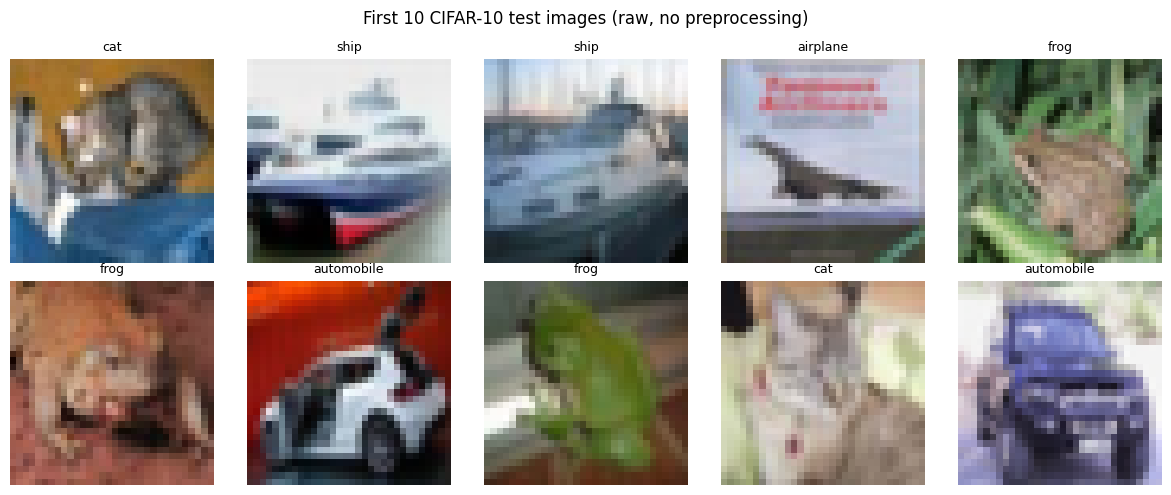

In [21]:
def tensor_to_pil(tensor: torch.Tensor) -> Image.Image:
    """Convert a C*H*W float32 [0,1] tensor to a PIL RGB image with NO preprocessing."""
    # Clamp to [0,1], scale to uint8, permute to H×W×C
    arr = (tensor.clamp(0, 1) * 255).byte().permute(1, 2, 0).numpy()
    return Image.fromarray(arr, mode='RGB')

# Quick visual sanity check
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, idx in zip(axes.ravel(), range(10)):
    img_tensor, label_idx = test_dataset[idx]
    ax.imshow(tensor_to_pil(img_tensor))
    ax.set_title(LABELS[label_idx], fontsize=9)
    ax.axis('off')
plt.suptitle('First 10 CIFAR-10 test images (raw, no preprocessing)', fontsize=12)
plt.tight_layout()
plt.show()

## 2. Load Gemma-4-31B-IT

We load the model in `bfloat16` with automatic device mapping so it spreads across available GPUs (or falls back to CPU with 4-bit quantisation if VRAM is limited).

In [22]:
from transformers import AutoProcessor, AutoModelForCausalLM
import torch

MODEL_ID = "google/gemma-4-31B-it"

print(f"Loading processor for {MODEL_ID} ...")
processor = AutoProcessor.from_pretrained(MODEL_ID)

print(f"Loading model {MODEL_ID} ...")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    dtype="auto",       # lets the model pick bfloat16 automatically
    device_map="auto",  # shards across available GPUs
)
model.eval()
print("Model loaded.")
print(f"Device map: {model.hf_device_map}" if hasattr(model, "hf_device_map") else "")

Loading processor for google/gemma-4-31B-it ...
Loading model google/gemma-4-31B-it ...


Loading weights:   0%|          | 0/1188 [00:00<?, ?it/s]

Model loaded.



## 3. Define the Zero-Shot Classifier

The `recognize` function mirrors the interface from the original notebook: it accepts a **raw image** (here a `torch.Tensor` or `PIL.Image`) and returns the predicted string label.

The prompt is designed to elicit a single-word answer constrained to the CIFAR-10 label set.

In [23]:
SYSTEM_PROMPT = (
    "You are an image classification assistant. "
    "You will be shown a small 32*32 pixel image. "
    "Your task is to classify it into exactly one of these ten categories: "
    + ", ".join(LABELS) + ". "
    "Reply with ONLY the category name — nothing else, no punctuation, no explanation."
)

def recognize(image, max_new_tokens: int = 20) -> str:
    if isinstance(image, torch.Tensor):
        pil_image = tensor_to_pil(image)
    else:
        pil_image = image

    messages = [
        {
            "role": "system",
            "content": [{"type": "text", "text": SYSTEM_PROMPT}]
        },
        {
            "role": "user",
            "content": [
                {"type": "image", "image": pil_image},   # PIL image passed directly here
                {"type": "text",  "text": "What object is in this image?"},
            ],
        },
    ]

    # Single call: tokenizes text AND processes image together
    inputs = processor.apply_chat_template(
        messages,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
        add_generation_prompt=True,
    ).to(model.device)

    input_len = inputs["input_ids"].shape[-1]

    with torch.inference_mode():
        outputs = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)

    # decode with skip_special_tokens=False so parse_response can see thinking tags
    raw = processor.decode(outputs[0][input_len:], skip_special_tokens=False)

    # parse_response returns a dict — text is at ["content"]
    result = processor.parse_response(raw)
    text_out = result["content"].strip().lower()

    for label in LABELS:
        if label in text_out:
            return label
    return text_out
print("recognize() function defined.")

recognize() function defined.


## 4. Single-Image Demo

Mirrors Task 3 from the original notebook.

Gemma-4 predicts : frog
True label       : frog
Correct          : True


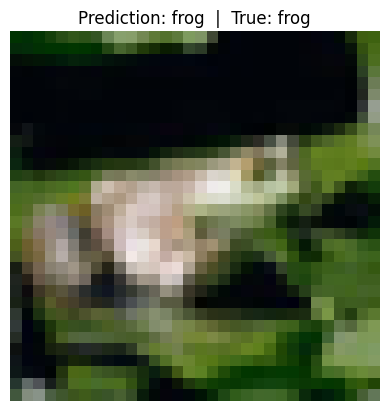

In [24]:
i = 62
img_tensor, true_label_idx = test_dataset[i]

pred = recognize(img_tensor)
true_label = LABELS[true_label_idx]

print(f"Gemma-4 predicts : {pred}")
print(f"True label       : {true_label}")
print(f"Correct          : {pred == true_label}")

plt.imshow(tensor_to_pil(img_tensor))
plt.title(f"Prediction: {pred}  |  True: {true_label}", fontsize=12)
plt.axis('off')
plt.show()

## 5. Batch Evaluation on the Test Set

Because each call is a full model forward pass, inference is slower than a trained CNN. We evaluate on a configurable subset (default 500 images) and extrapolate accuracy.

> **Tip:** Set `NUM_SAMPLES = len(test_dataset)` (10 000) for a full evaluation, but expect ~several hours on a single GPU.

In [ ]:
import time
from tqdm.auto import tqdm

NUM_SAMPLES = 500  # increase for a more rigorous evaluation

# Optionally fix a seed for reproducible subset selection
rng = np.random.default_rng(42)
indices = rng.choice(len(test_dataset), size=NUM_SAMPLES, replace=False)

correct = 0
predictions = []
true_labels  = []

start_time = time.time()

for idx in tqdm(indices, desc="Classifying"):
    img_tensor, label_idx = test_dataset[int(idx)]
    pred = recognize(img_tensor)
    true = LABELS[label_idx]

    predictions.append(pred)
    true_labels.append(true)
    if pred == true:
        correct += 1

elapsed = time.time() - start_time
accuracy = correct / NUM_SAMPLES * 100

print(f"\nEvaluated {NUM_SAMPLES} images in {elapsed/60:.1f} min")
print(f"Zero-shot accuracy : {accuracy:.1f}%  ({correct}/{NUM_SAMPLES})")

Classifying:   0%|          | 0/500 [00:00<?, ?it/s]

## 6. Per-Class Accuracy

In [ ]:
from collections import defaultdict

class_correct = defaultdict(int)
class_total   = defaultdict(int)

for pred, true in zip(predictions, true_labels):
    class_total[true] += 1
    if pred == true:
        class_correct[true] += 1

print(f"{'Class':<12}  {'Correct':>7}  {'Total':>6}  {'Acc':>6}")
print("-" * 38)
for label in LABELS:
    n  = class_total[label]
    c  = class_correct[label]
    acc = c / n * 100 if n > 0 else 0
    print(f"{label:<12}  {c:>7}  {n:>6}  {acc:>5.1f}%")

# Bar chart
accs = [class_correct[l] / class_total[l] * 100 if class_total[l] > 0 else 0 for l in LABELS]
plt.figure(figsize=(10, 4))
bars = plt.bar(LABELS, accs, color='steelblue', edgecolor='white')
plt.axhline(accuracy, color='crimson', linestyle='--', label=f'Overall {accuracy:.1f}%')
plt.ylim(0, 105)
plt.ylabel('Accuracy (%)')
plt.title(f'Gemma-4 Zero-Shot CIFAR-10 Accuracy by Class (n={NUM_SAMPLES})')
plt.legend()
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{acc:.0f}%', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

## 7. Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Map predictions to LABELS indices (unknown predictions map to -1)
def label_to_idx(label):
    return LABELS.index(label) if label in LABELS else -1

y_true = [label_to_idx(l) for l in true_labels]
y_pred = [label_to_idx(l) for l in predictions]

# Filter out any -1 (unrecognised outputs)
pairs = [(t, p) for t, p in zip(y_true, y_pred) if t >= 0 and p >= 0]
y_true_f, y_pred_f = zip(*pairs)

cm = confusion_matrix(y_true_f, y_pred_f, labels=range(10))

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABELS)
disp.plot(ax=ax, colorbar=False, cmap='Blues', xticks_rotation=45)
ax.set_title(f'Gemma-4 Zero-Shot Confusion Matrix (n={len(pairs)})', fontsize=13)
plt.tight_layout()
plt.show()

## 8. Qualitative Error Analysis

Show a grid of misclassified images to inspect failure modes.

In [ ]:
errors = [(int(indices[i]), pred, true)
          for i, (pred, true) in enumerate(zip(predictions, true_labels))
          if pred != true]

NUM_SHOW = min(20, len(errors))
cols = 5
rows = (NUM_SHOW + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 3))
for ax, (idx, pred, true) in zip(axes.ravel(), errors[:NUM_SHOW]):
    img_tensor, _ = test_dataset[idx]
    ax.imshow(tensor_to_pil(img_tensor))
    ax.set_title(f"True: {true}\nPred: {pred}", fontsize=8,
                 color='red' if pred != true else 'green')
    ax.axis('off')

# Hide any unused subplots
for ax in axes.ravel()[NUM_SHOW:]:
    ax.set_visible(False)

plt.suptitle(f'Gemma-4 Misclassified Images (showing {NUM_SHOW}/{len(errors)} errors)',
             fontsize=12)
plt.tight_layout()
plt.show()